# Predicting Used Car Prices

## 1. Business Understanding

## 2. Data Understanding & Loading

## 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis

### 3.2 Bivariate Analysis (Price vs Features)

### 3.3 Correlation Analysis

## 4. Data Preprocessing

### 4.1 Handling Missing Values

### 4.2 Encoding Categorical Variables

### 4.3 Feature Scaling (if needed)

## 5. Feature Engineering

### 5.1 Creating New Features (e.g., Car Age)

### 5.2 Feature Selection / Importance

## 6. Model Building

### 6.1 Train-Test Split

### 6.2 Baseline Models

### 6.3 Decision Tree Regressor

### 6.4 Random Forest Regressor

### 6.5 (Optional) Other Models

## 7. Model Evaluation & Comparison

## 8. Conclusions & Business Insights

## 9. Save Final Model (Optional)


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


In [4]:
# Load dataset
df = pd.read_csv("../data/raw/usedCars.csv")

df.head()


,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


In [5]:
# Shape of the dataset
df.shape


(1064, 19)

In [6]:
# Data types and info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


In [7]:
# Check missing values
df.isnull().sum()


Id                     0
Company                0
Model                  0
Variant                0
FuelType               1
Colour                 0
Kilometer              0
BodyStyle              0
TransmissionType     714
ManufactureDate        0
ModelYear              0
CngKit              1042
Price                  0
Owner                  0
DealerState            0
DealerName             0
City                   0
Warranty               0
QualityScore           0
dtype: int64

In [8]:
# Summary statistics for numeric columns
df.describe()


,Id,Kilometer,ModelYear,Warranty,QualityScore
count,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000
mean,568156.542293,52807.187970,2016.864662,0.738722,7.770207
std,16438.139974,33840.296979,2.996786,0.439538,0.719717
min,525978.000000,101.000000,2003.000000,0.000000,0.000000
25%,555321.500000,32113.500000,2015.000000,0.000000,7.500000
50%,572753.000000,49432.000000,2017.000000,1.000000,7.800000
75%,583072.750000,68828.500000,2019.000000,1.000000,8.100000
max,589122.000000,640000.000000,2023.000000,1.000000,9.400000


In [9]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols


Index(['Id', 'Kilometer', 'ModelYear', 'Warranty', 'QualityScore'], dtype='object')

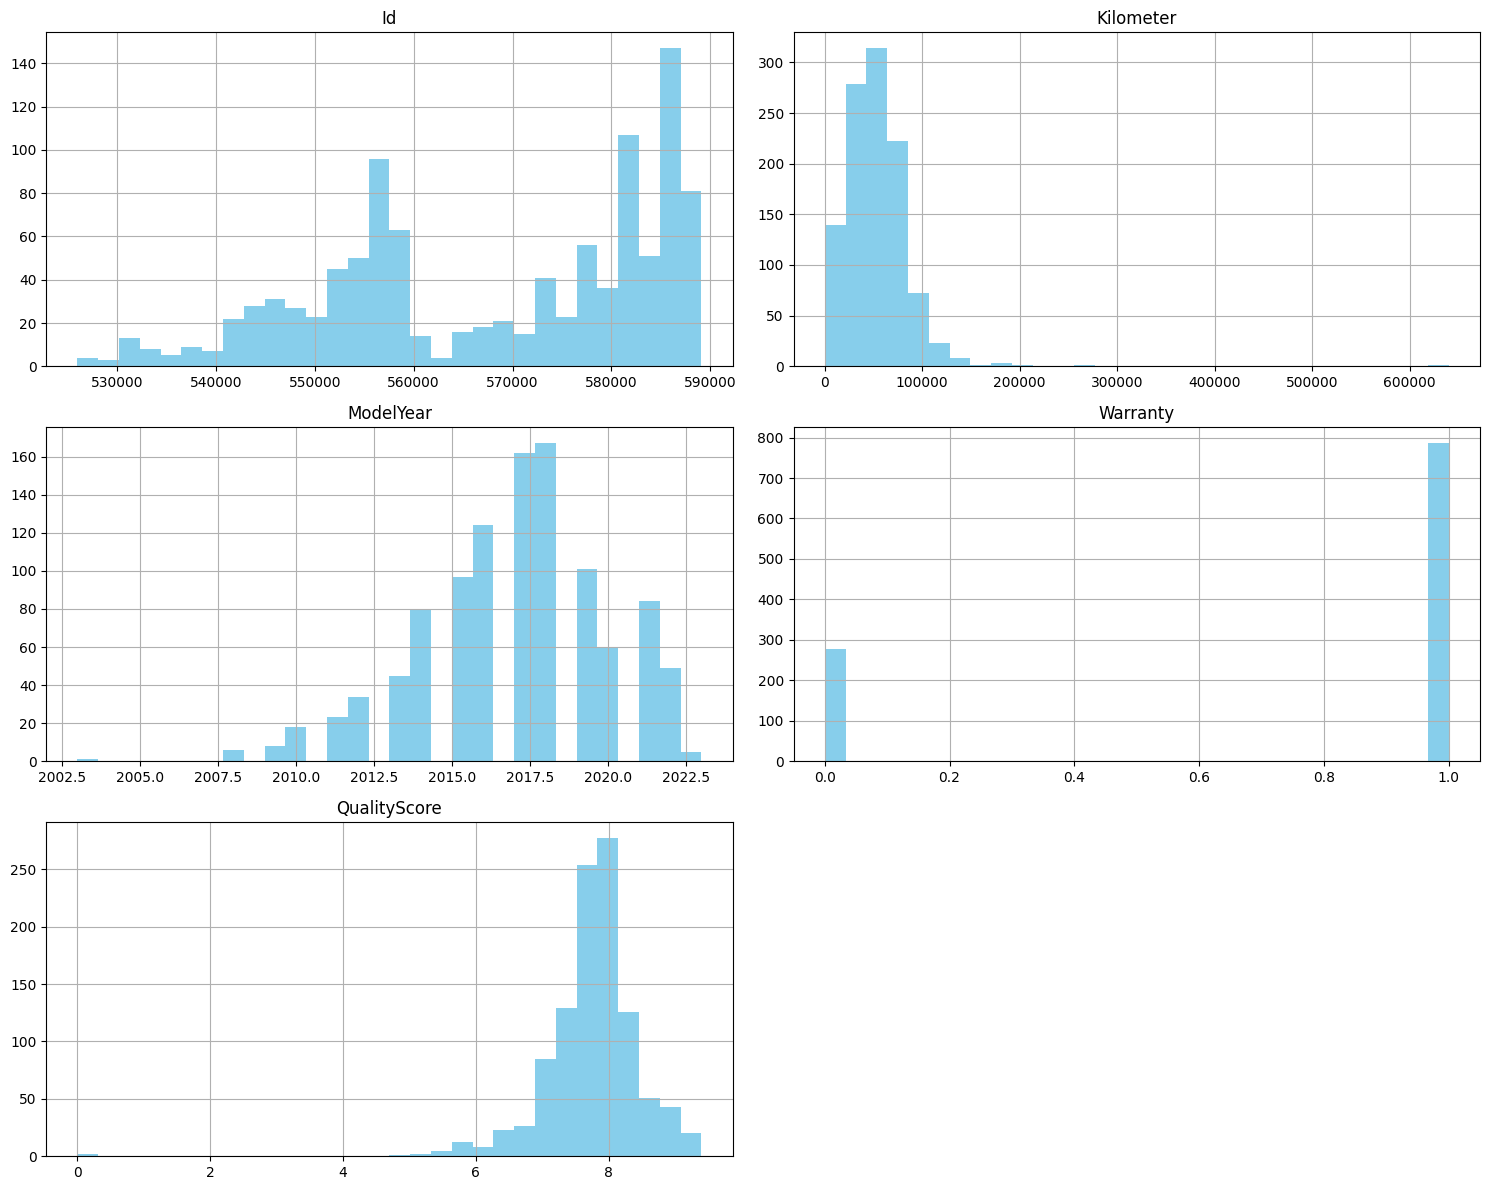

In [10]:
# Plot histograms for numeric columns
df[numeric_cols].hist(bins=30, figsize=(15, 12), color='skyblue')
plt.tight_layout()
plt.show()


In [11]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols


Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'ManufactureDate', 'CngKit', 'Price', 'Owner',
       'DealerState', 'DealerName', 'City'],
      dtype='object')

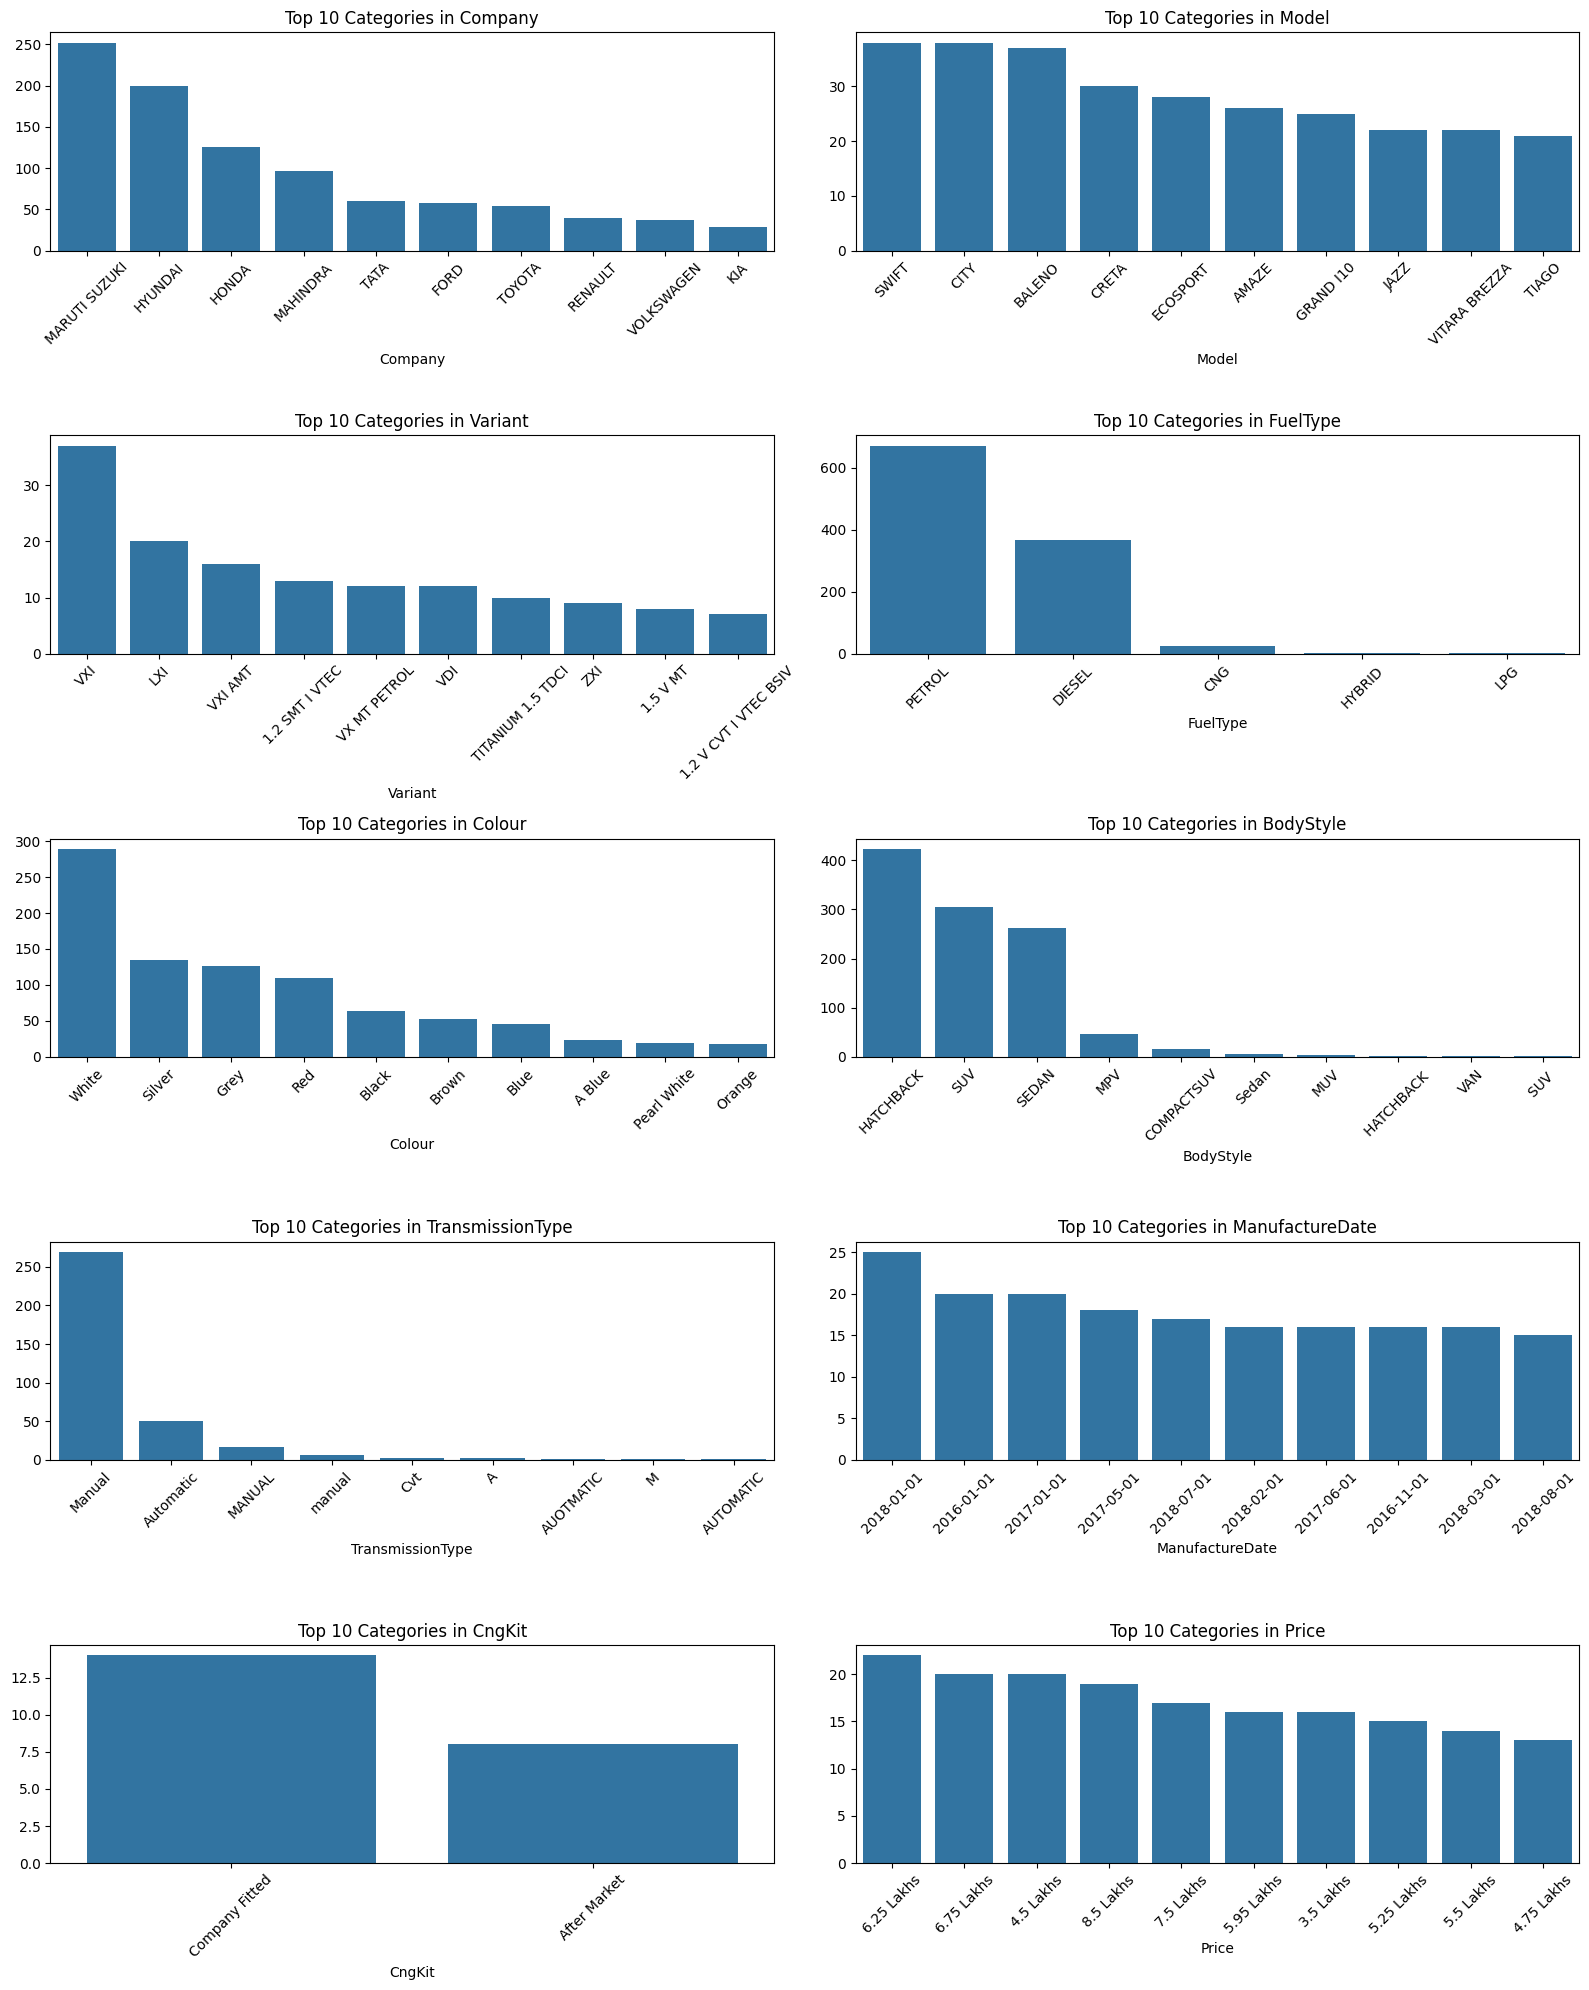

In [12]:
# Clean categorical plots (Top 10 values only)

plt.figure(figsize=(16, 20))

for i, col in enumerate(categorical_cols[:10]):
    plt.subplot(5, 2, i+1)
    top_10 = df[col].value_counts().head(10)
    sns.barplot(x=top_10.index, y=top_10.values)
    plt.xticks(rotation=45)
    plt.title(f"Top 10 Categories in {col}")

plt.tight_layout()
plt.show()



In [13]:
df[categorical_cols].nunique()


Company              23
Model               218
Variant             575
FuelType              5
Colour               76
BodyStyle            10
TransmissionType      9
ManufactureDate     162
CngKit                2
Price               367
Owner                 4
DealerState          10
DealerName           57
City                 11
dtype: int64

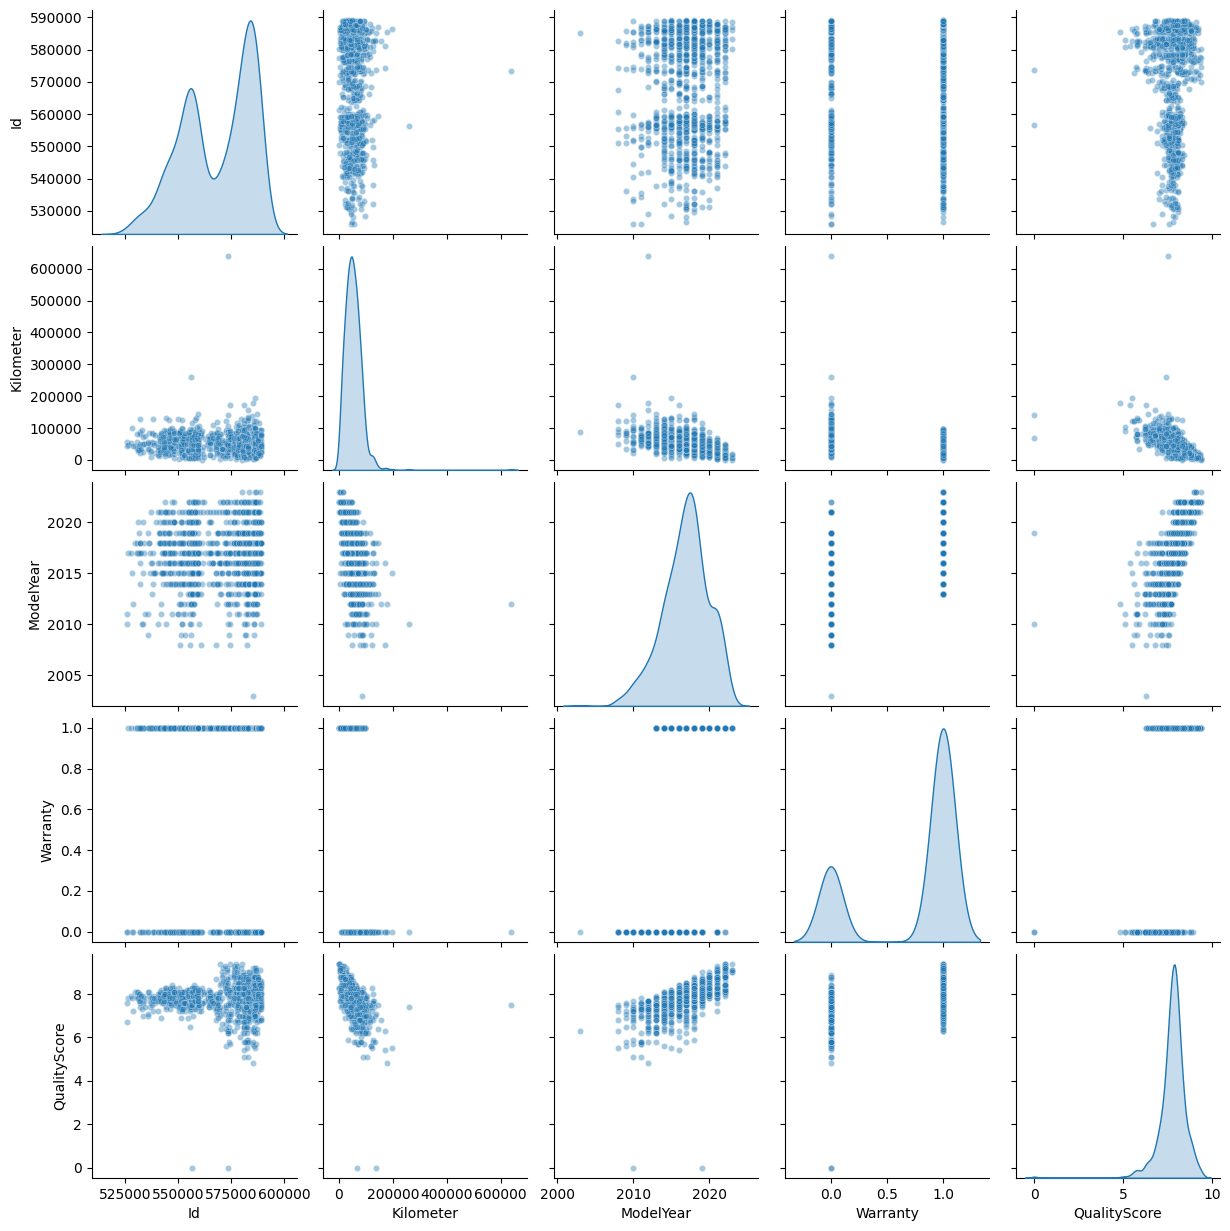

In [14]:
# Clean pairplot for numeric variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
plt.show()




In [15]:
# Convert Price to numeric (remove commas, currency symbols, spaces etc.)
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('[^0-9.]', '', regex=True)  # keep only digits and dot
    .replace('', np.nan)
    .astype(float)
)

df['Price'].head(), df['Price'].dtype


(0    5.75
 1    4.35
 2    4.70
 3    9.90
 4    2.70
 Name: Price, dtype: float64,
 dtype('float64'))

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols


Index(['Id', 'Kilometer', 'ModelYear', 'Price', 'Warranty', 'QualityScore'], dtype='object')

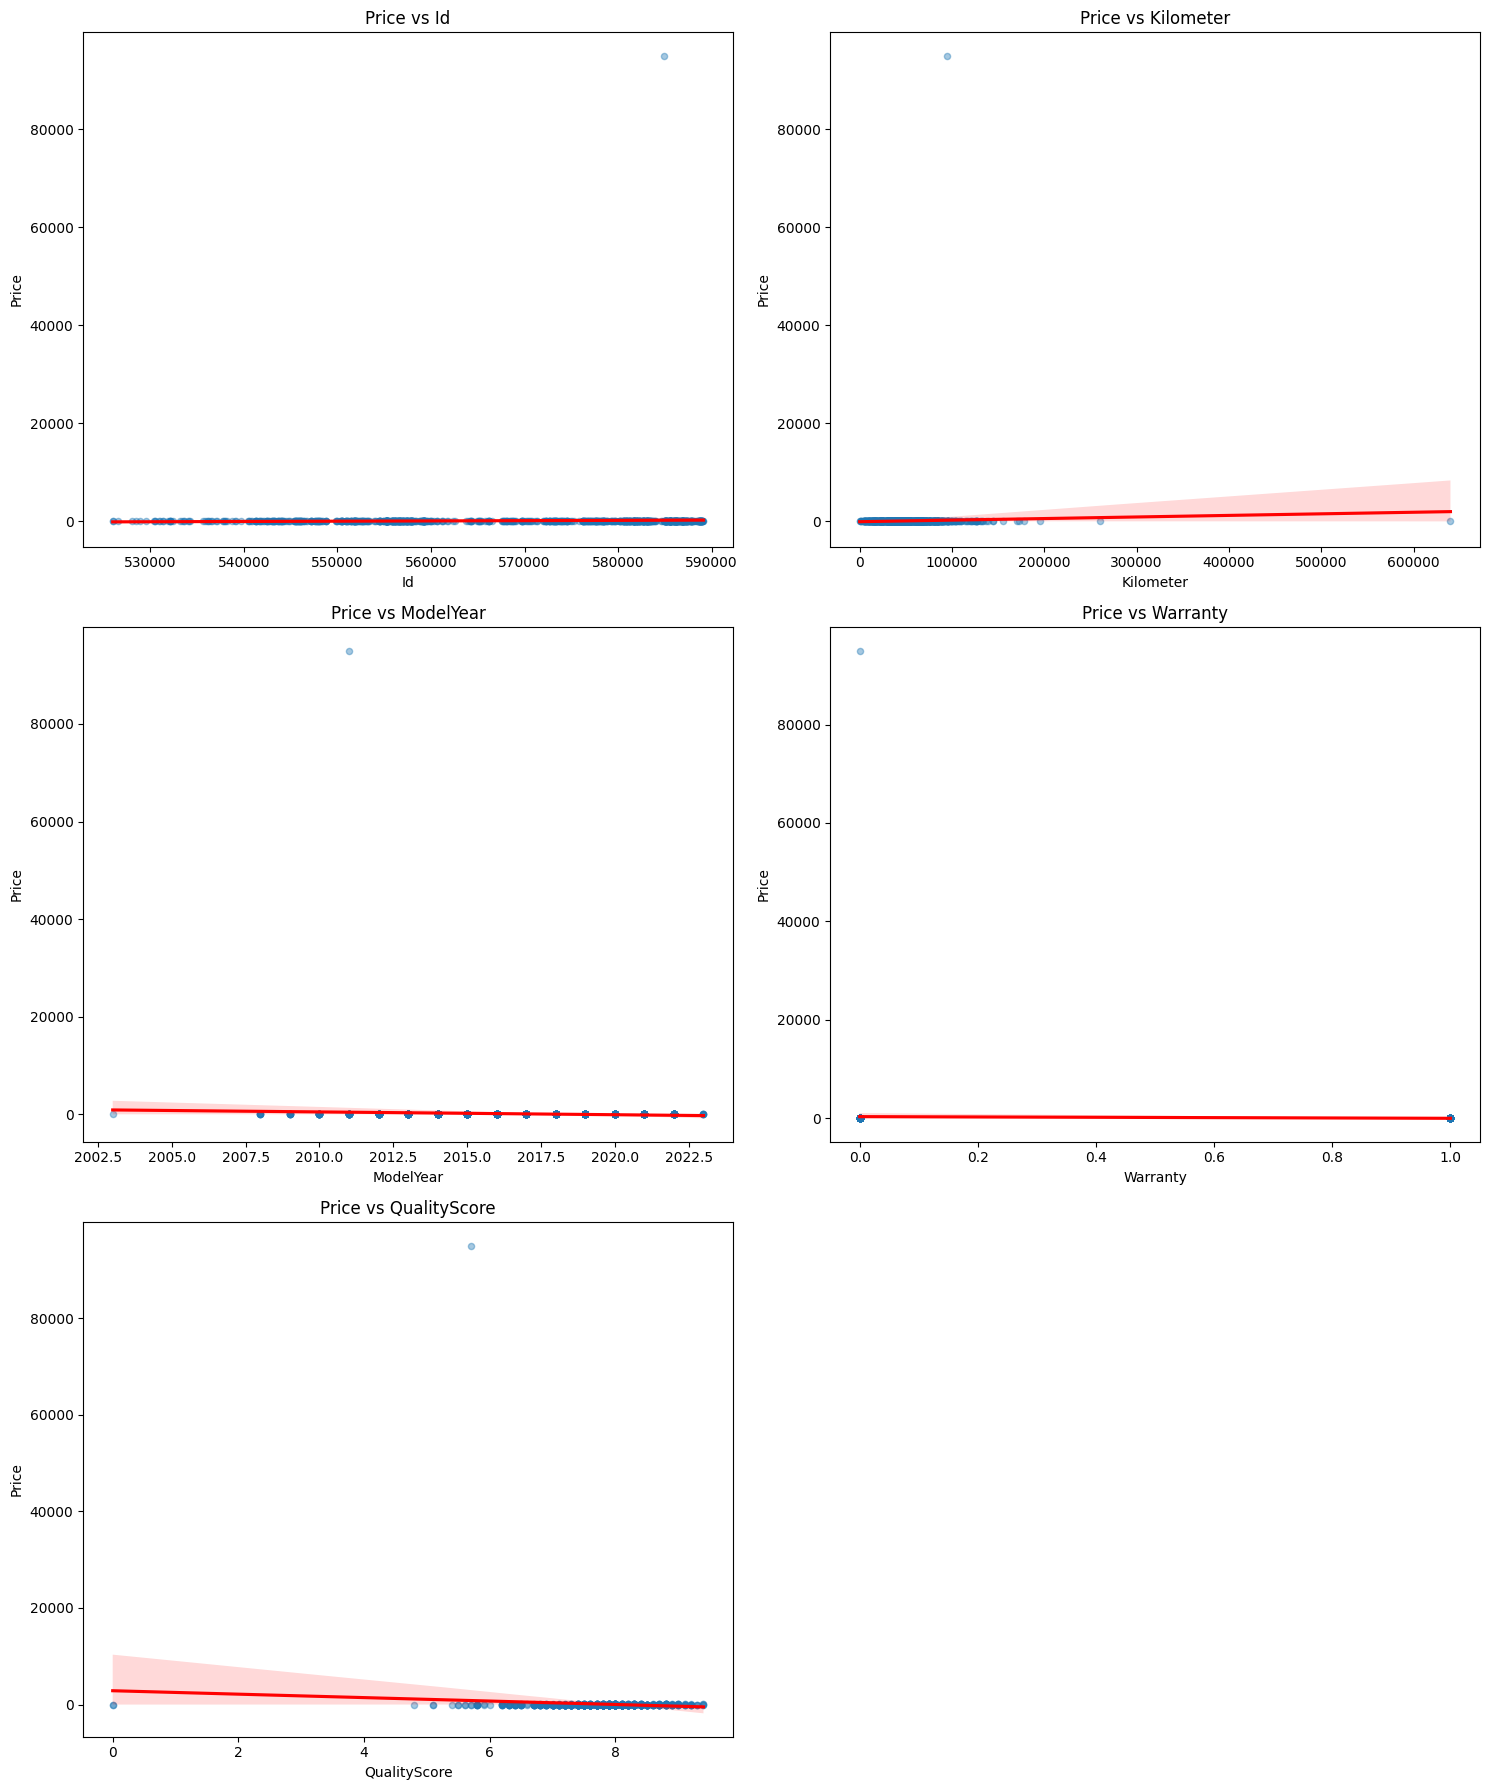

In [17]:
plt.figure(figsize=(15, 18))

for i, col in enumerate([c for c in numeric_cols if c != "Price"][:6]):  # avoid using Price on x
    plt.subplot(3, 2, i+1)
    sns.regplot(
        data=df,
        x=col,
        y="Price",
        scatter_kws={'alpha': 0.4, 's': 20},
        line_kws={'color': 'red'}
    )
    plt.title(f"Price vs {col}")
    plt.xlabel(col)
    plt.ylabel("Price")

plt.tight_layout()
plt.show()


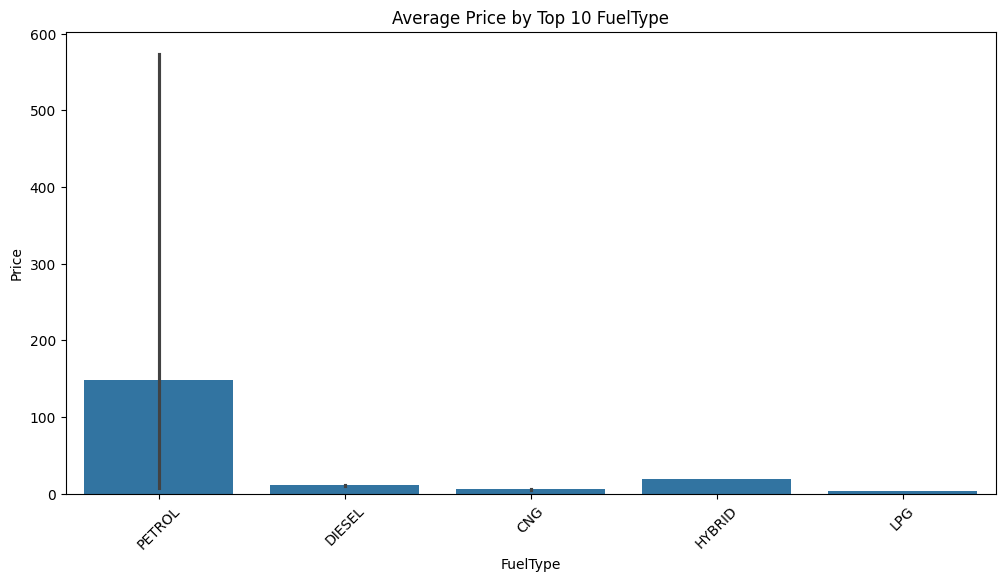

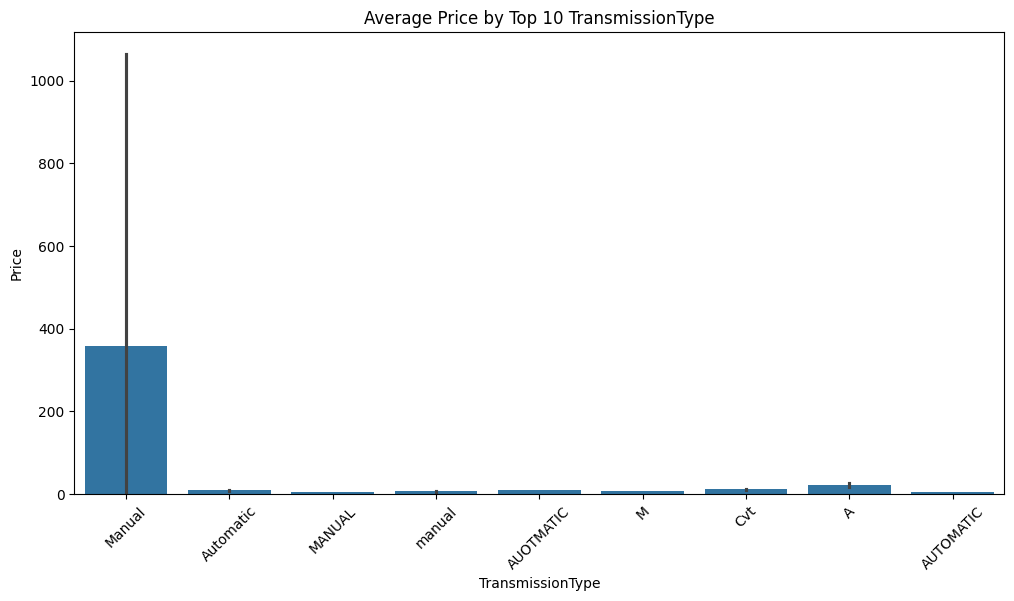

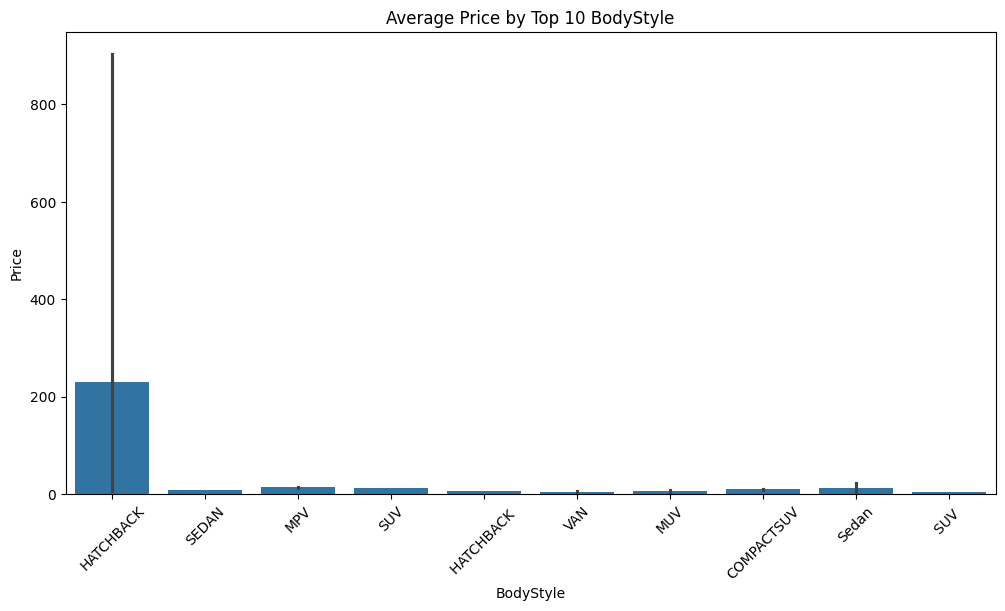

In [18]:
def plot_price_by_category(col):
    top_10 = df[col].value_counts().head(10).index

    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df[df[col].isin(top_10)],
        x=col,
        y="Price",
        estimator='mean'
    )
    plt.xticks(rotation=45)
    plt.title(f"Average Price by Top 10 {col}")
    plt.show()

plot_price_by_category("FuelType")
plot_price_by_category("TransmissionType")
plot_price_by_category("BodyStyle")


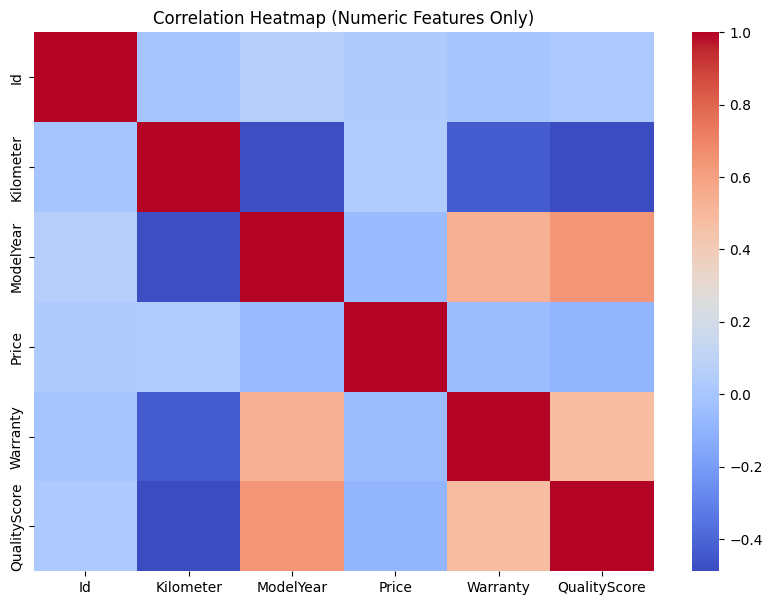

In [19]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


In [20]:
df.select_dtypes(include=['object']).columns


Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'ManufactureDate', 'CngKit', 'Owner', 'DealerState',
       'DealerName', 'City'],
      dtype='object')

In [21]:
# Missing values summary
df.isnull().sum().sort_values(ascending=False)


CngKit              1042
TransmissionType     714
FuelType               1
Model                  0
Company                0
Id                     0
Colour                 0
Kilometer              0
BodyStyle              0
ManufactureDate        0
Variant                0
ModelYear              0
Price                  0
Owner                  0
DealerState            0
DealerName             0
City                   0
Warranty               0
QualityScore           0
dtype: int64

In [22]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [23]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [24]:
if 'Kilometers_Driven' in df.columns:
    df['Kilometers_Driven'] = (
        df['Kilometers_Driven']
        .astype(str)
        .str.replace('[^0-9.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
        .fillna(df['Kilometers_Driven'].median())
    )


In [25]:
if 'Engine' in df.columns:
    df['Engine'] = (
        df['Engine']
        .astype(str)
        .str.extract('(\d+)')
        .astype(float)
    )


In [26]:
if 'Mileage' in df.columns:
    df['Mileage'] = (
        df['Mileage']
        .astype(str)
        .str.extract('(\d+\.?\d*)')
        .astype(float)
    )


In [27]:
import datetime
current_year = datetime.datetime.now().year

if 'Year' in df.columns:
    df['Car_Age'] = current_year - df['Year']


In [28]:
columns_to_drop = ['Car_ID', 'VIN', 'RegistrationDate', 'ManufactureDate']

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)


In [29]:
# Recompute categorical and numeric columns after cleaning
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols, numeric_cols


(Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
        'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'DealerName',
        'City'],
       dtype='object'),
 Index(['Id', 'Kilometer', 'ModelYear', 'Price', 'Warranty', 'QualityScore'], dtype='object'))

In [30]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()

# Columns with fewer than or equal to 20 unique categories
simple_cat_cols = [col for col in categorical_cols if df[col].nunique() <= 20]

simple_cat_cols


['FuelType',
 'BodyStyle',
 'TransmissionType',
 'CngKit',
 'Owner',
 'DealerState',
 'City']

In [31]:
for col in simple_cat_cols:
    df[col] = label_enc.fit_transform(df[col])


In [32]:
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col not in simple_cat_cols], drop_first=True)


In [33]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Columns: 957 entries, Id to DealerName_Zippy Automart
dtypes: bool(944), float64(2), int64(11)
memory usage: 1.1 MB


,Id,FuelType,Kilometer,BodyStyle,TransmissionType,ModelYear,CngKit,Price,Owner,DealerState,City,Warranty,QualityScore,Company_BMW,Company_CHEVROLET,Company_DATSUN,Company_FIAT,Company_FORD,Company_HONDA,Company_HYUNDAI,Company_ISUZU,Company_JEEP,Company_KIA,Company_MAHINDRA,Company_MARUTI SUZUKI,Company_MERCEDES BENZ,Company_MG,Company_MITSUBISHI,Company_NISSAN,Company_RENAULT,Company_SKODA,Company_TATA,Company_TOYOTA,Company_VOLKSWAGEN,Company_VOLVO,Model_5 SERIES,Model_A STAR,Model_A3,Model_A3(2014-2017),Model_A4,Model_A6,Model_A6(2011-2015),Model_ACCENT,Model_ACCORD,Model_ALCAZAR(2021-2023),Model_ALTO,Model_ALTO 800,Model_ALTO K10,Model_ALTROZ,Model_AMAZE,Model_AMEO,Model_ASPIRE,Model_ASPIRE(2015_2018),Model_ASTOR,Model_AURA,Model_BALENO,Model_BALENO(2020-2022),Model_BOLERO,Model_BOLERO(2007-2011),Model_BR V,Model_BRIO,Model_C CLASS,Model_CAMRY,Model_CAPTUR,Model_CARENS,Model_CELERIO,Model_CELERIO X,Model_CELERIO X(2020-2021),Model_CELERIO(2017-2019),Model_CIAZ,Model_CIAZ(2018-2020),Model_CITY,Model_CITY 5TH GEN,Model_CITY ZX,Model_CITY(2008-2011),Model_CITY(2011-2014),Model_CITY(2014-2017),Model_CITY(2017-2020),Model_CLA,Model_CLA CLASS,Model_COMPASS,Model_COMPASS(2020-2021),Model_COMPASS(2021-2023),Model_COROLLA ALTIS,Model_COROLLA ALTIS(2014-2017),Model_COROLLA ALTIS(2017-2020),Model_CRETA,Model_CRETA(2018-2019),Model_CRETA(2020-2023),Model_CRV,Model_DUSTER,Model_DUSTER(2016-2019),Model_DZIRE,Model_DZIRE(2017-2020),Model_DZIRE(2017_2020),Model_E CLASS,Model_E-CLASS(2009-2013),Model_E-CLASS(2013-2015),Model_E-CLASS(2015-2017),Model_ECOSPORT,Model_ECOSPORT(2017-2019),Model_ECOSPORT(2021-2022),Model_EECO,Model_ELANTRA,Model_ELANTRA(2016-2019),Model_ELITE I20,Model_ELITE I20(2018-2019),Model_ELITE I20(2020-2020),Model_ENDEAVOUR,Model_ENDEAVOUR(2016_2019),Model_EON,Model_ERTIGA,Model_ERTIGA(2015-2018),Model_ERTIGA(2018-2022),Model_ETIOS,Model_ETIOS CROSS,Model_FIESTA(2008-2011),Model_FIGO,Model_FIGO ASPIRE,Model_FIGO(2012-2015),Model_FORTUNER,Model_FORTUNER (2012_2016),Model_GLANZA,Model_GLANZA(2020-2022),Model_GO,Model_GRAND I10,Model_GRAND I10 NIOS,Model_GRAND I10 NIOS(2019-2023),Model_GRAND I10(2013-2017),Model_GRAND I10(2017-2020),Model_GRAND PUNTO,Model_HARRIER,Model_HECTOR,Model_HECTOR PLUS,Model_HECTOR PLUS(2021-2023),Model_HECTOR(2020-2021),Model_HECTOR(2021-2023),Model_HEXA,Model_I10,Model_I10(2010_2017),Model_I20,Model_I20 ACTIVE,Model_I20(2012-2014),Model_I20(2015-2017),Model_IGNIS,Model_INNOVA,Model_INNOVA CRYSTA,Model_INNOVA(2012-2013),Model_JAZZ,Model_KICKS,Model_KIGER,Model_KIGER(2021-2022),Model_KIGER(2022-2023),Model_KODIAQ,Model_KUSHAQ,Model_KUV100,Model_KUV100 NXT,Model_KUV100(2016_2017),Model_KWID,Model_KWID(2015_2019),Model_KWID(2020-2021),Model_MAGNITE,Model_MANZA(2011_2015),Model_MARAZZO,Model_MICRA,Model_MICRA ACTIVE,Model_ML CLASS,Model_MOBILIO,Model_NEW ELANTRA,Model_NEXON,Model_OCTAVIA,Model_OCTAVIA(2015-2017),Model_PAJERO SPORT,Model_PLATINUM ETIOS,Model_POLO,Model_POLO(2012-2014),Model_Q3,Model_Q3 2.0,Model_Q3(2012-2015),Model_RAPID,Model_RAPID(2011-2014),Model_RAPID(2016-2020),Model_RITZ,Model_S CROSS,Model_S PRESSO,Model_S-CROSS(2017-2020),Model_SAFARI,Model_SAIL UVA,Model_SANTRO,Model_SANTRO XING,Model_SANTRO(2018-2020),Model_SANTRO(2020-2023),Model_SCORPIO,Model_SCORPIO CLASSIC,Model_SCORPIO(2009-2014),Model_SCORPIO(2014-2017),Model_SELTOS,Model_SELTOS(2020-2022),Model_SONET,Model_SPARK,Model_SUNNY,Model_SUPERB,Model_SWIFT,Model_SWIFT DZIRE,Model_SWIFT(2014_2018),Model_SWIFT(2018_2019),Model_TAIGUN,Model_TERRANO,Model_THAR,Model_TIAGO,Model_TIGOR,Model_TIGOR(2018-2020),Model_TIGUAN,Model_TRIBER,Model_TUCSON,Model_TUV 300,Model_URBAN CRUISER,Model_URBAN CRUISER HYRYDER,Model_V CROSS,Model_V40,Model_VENTO,Model_VENUE,Model_VENUE(2020-2022),Model_VERITO(2011-2012),Model_VERNA,Model_VERNA(2017-2020),Model_VIRTUS,Model_VITARA BREZZA,Model_WAGON R,Model_WAGON R 1.0,Model_WAGON R(2019-2022),Model_WR V,Model_WR-V,Model_WRANGLER,Model_X1,Model_X1(2010-2012),Model_XC 60,Model_XCENT,Model_XCENT(2014-2017

In [34]:
# Convert Price from lakhs to rupees
df["Price"] = df["Price"] * 100000

df["Price"].head()  # optional, just to check


0    575000.0
1    435000.0
2    470000.0
3    990000.0
4    270000.0
Name: Price, dtype: float64

In [35]:
# Remove extreme unrealistic price outliers (anything above 50 lakh)
df = df[df["Price"] < 5000000]


In [36]:
# Separate features (X) and target (y)
X = df.drop("Price", axis=1)
y = df["Price"]

# Train-test split (80% training, 20% testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((849, 956), (213, 956))

In [37]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


In [39]:
dt_results = evaluate_model(y_test, dt_pred)
dt_results


{'MSE': 154266262910.79813,
 'MAE': 226666.66666666666,
 'RMSE': np.float64(392767.4412560162),
 'R2 Score': 0.4621024796196137}

In [40]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_results = evaluate_model(y_test, rf_pred)
rf_results


{'MSE': 98934630359.15492,
 'MAE': 172326.43192488264,
 'RMSE': np.float64(314538.75811917824),
 'R2 Score': 0.6550335028164183}

In [41]:
results_df = pd.DataFrame({
    "Decision Tree": dt_results,
    "Random Forest": rf_results
})

results_df


,Decision Tree,Random Forest
MSE,1.542663e+11,9.893463e+10
MAE,2.266667e+05,1.723264e+05
RMSE,3.927674e+05,3.145388e+05
R2 Score,4.621025e-01,6.550335e-01


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a dataframe
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp_df.head(20)


,Feature,Importance
3,BodyStyle,0.275671
5,ModelYear,0.153953
145,Model_INNOVA CRYSTA,0.057671
2,Kilometer,0.051246
119,Model_FORTUNER,0.046462
24,Company_MERCEDES BENZ,0.023856
0,Id,0.021657
833,Colour_Black,0.021637
1,FuelType,0.016719
31,Company_TOYOTA,0.016651


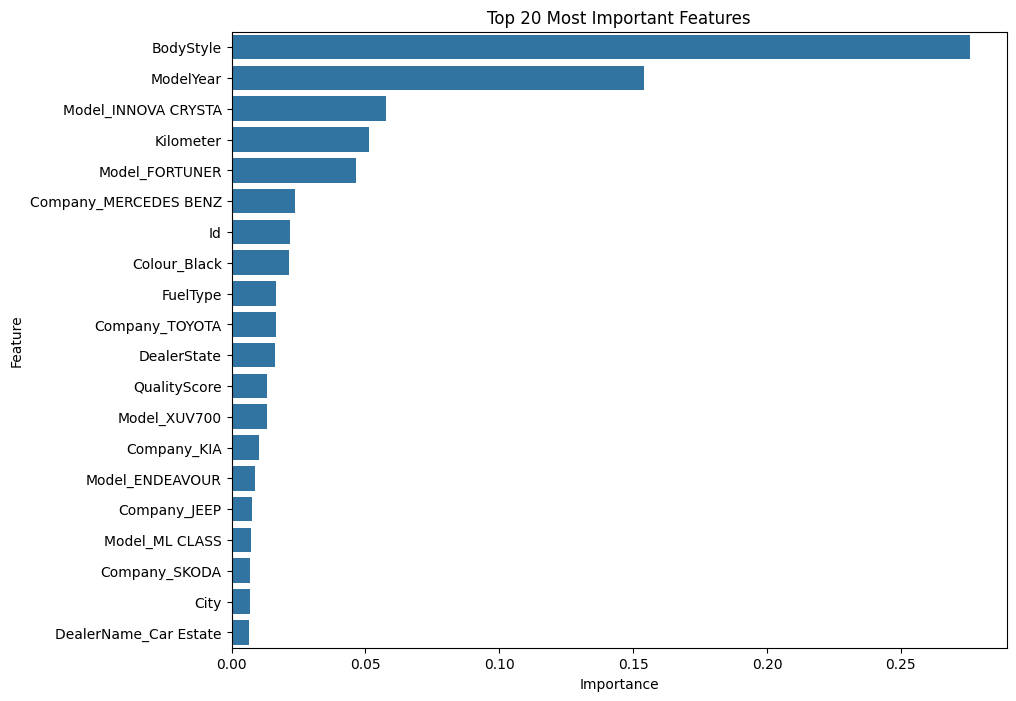

In [43]:
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(20))
plt.title("Top 20 Most Important Features")
plt.show()


In [44]:
import os

# Create folder if it doesn't exist
os.makedirs("../models/saved_models", exist_ok=True)


In [45]:
import joblib

# Save final Random Forest model
joblib.dump(rf_model, "../models/saved_models/random_forest_model.pkl")


['../models/saved_models/random_forest_model.pkl']

In [46]:
df.to_csv("../data/processed/usedCars_processed.csv", index=False)


In [49]:
feat_imp_df.to_csv("../data/importance.csv", index=False)

